# 선형회귀(Linear Regression)

## 머신러닝 (Machine Learning)
명시적으로 규칙을 프로그래밍하지 않고, 데이터로부터 패턴을 학습하여 예측,판단을 하는 기술

### 정통적인 프로그래밍
 - 데이터와 규칙을 입력을 준다.
 - 정답이 출력된다.
 - if 값 > 10000: 비싸다


### 머신러닝
 - 데이터와 정답이 입력으로 준다.
 - 모델(규칙)이 출력된다.
 - 값을 스스로 판단하여 비싼지 여부를 결정


### 머신러닝의 기본 흐름

1. 데이터 수집
2. 전처리(정제, 스케일링)
3. 학습(훈련)/테스트 데이터를 분리
4. 모델 학습
5. 평가
6. 예측


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['axes.unicode_minus'] = False # -(마이너스) 기호 깨짐 방지

%matplotlib inline

In [3]:
df = pd.read_csv('data/flight.csv')

df.head(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [4]:

df = df.drop(['Unnamed: 0'],axis=1)
df.head(3)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


## 인코딩(Encoding)
    - 범주형(문자열형) 데이터를 의미있는 수치형 데이터로 변환하는 알고리즘

    1. Label Encode
    2. Ordinary Encode
    3. One-Hot Encode


In [6]:
#
df_test = pd.DataFrame({
    'color' : ['Red', 'Green', 'Blue', 'Green', 'Red'],
    'size' : ['S', 'L', 'M', 'S', 'M'],
    'city' : ['Seoul', 'Busan', 'Daegu', 'Seoul', 'Busan'],
    'price' : [100, 250, 180, 200, 120]
})

df_test.head()

,color,size,city,price
0,Red,S,Seoul,100
1,Green,L,Busan,250
2,Blue,M,Daegu,180
3,Green,S,Seoul,200
4,Red,M,Busan,120


In [ ]:
# 라벨 인코더 하기

from sklearn.preprocessing import LabelEncoder
# 라벨 인코더 객체 생성
le = LabelEncoder()
df_test['size_le'] = le.fit_transform(df_test['size'])
df_test

,color,size,city,price,size_le
0,Red,S,Seoul,100,2
1,Green,L,Busan,250,0
2,Blue,M,Daegu,180,1
3,Green,S,Seoul,200,2
4,Red,M,Busan,120,1


In [9]:
#선수형 인코딩

size_map = {'S': 0, 'M': 1,  'L': 2}
df_test['size_ord'] = df_test['size'].map(size_map)
df_test

,color,size,city,price,size_le,size_ord
0,Red,S,Seoul,100,2,0
1,Green,L,Busan,250,0,2
2,Blue,M,Daegu,180,1,1
3,Green,S,Seoul,200,2,0
4,Red,M,Busan,120,1,1


In [11]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['S','M','L']])
df_test['size_ord2'] = oe.fit_transform(df_test[['size']]).astype(int)
df_test 

,color,size,city,price,size_le,size_ord,size_ord2
0,Red,S,Seoul,100,2,0,0
1,Green,L,Busan,250,0,2,2
2,Blue,M,Daegu,180,1,1,1
3,Green,S,Seoul,200,2,0,0
4,Red,M,Busan,120,1,1,1


In [12]:
df_test = df_test.drop(['size_le','size_ord','size_ord2'], axis=1)
df_test

,color,size,city,price
0,Red,S,Seoul,100
1,Green,L,Busan,250
2,Blue,M,Daegu,180
3,Green,S,Seoul,200
4,Red,M,Busan,120


In [13]:
# One-Hot Encoding
df_test_enc = pd.get_dummies(df_test['color'], prefix='color').astype(int)
df_test_enc

,color_Blue,color_Green,color_Red
0,0,0,1
1,0,1,0
2,1,0,0
3,0,1,0
4,0,0,1


In [ ]:
# One-Hot Encoding(Dummy Encoding) -> 선형회구에서 많이 사용함
df_test_enc = pd.get_dummies(df_test['color'], prefix='color', drop_first=True).astype(int)
df_test_enc

,color_Green,color_Red
0,0,1
1,1,0
2,0,0
3,1,0
4,0,1


## 스케일링(Scaling)

수치형 데이터들은 컬럼들간의 단위가 달란서 학습할때 연산에서 가중치가 적용될 수 있으므로 각 수치들을 평탄화하는 작업이 필요하다.

    1.Min-Max Scaling(졍규화) : 범위를 0~1사이로 변환

    2.Standard Scaling(표준화) : 평균을 0, 표준편차를 1로 만드는 정규분표 형태로 변환

    3.Robust Scalling: (값 - 중앙값) / IQR

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

ss = StandardScaler()
ms = MinMaxScaler()
rs = RobustScaler()

#수치형 데이터들의 컬럼들만 추출
cols = df.select_dtypes(include='number').columns
#표준화 적용
df_ss =  pd.DataFrame(ss.fit_transform(df[cols]),columns=cols)
df_ss.head()

,duration,days_left,price
0,-1.397531,-1.843875,-0.658068
1,-1.375284,-1.843875,-0.658068
2,-1.397531,-1.843875,-0.657936
3,-1.386407,-1.843875,-0.657980
4,-1.375284,-1.843875,-0.657980


In [19]:
#정규화(Min-Max Scaling) 적용
df_ms =  pd.DataFrame(ms.fit_transform(df[cols]),columns=cols)
df_ms.head()

,duration,days_left,price
0,0.027347,0.0,0.039749
1,0.030612,0.0,0.039749
2,0.027347,0.0,0.039773
3,0.028980,0.0,0.039765
4,0.030612,0.0,0.039765


In [20]:
#Rubust Scaling  적용
df_rs =  pd.DataFrame(rs.fit_transform(df[cols]),columns=cols)
df_rs.head()

,duration,days_left,price
0,-0.972163,-1.086957,-0.039006
1,-0.955032,-1.086957,-0.039006
2,-0.972163,-1.086957,-0.038926
3,-0.963597,-1.086957,-0.038953
4,-0.955032,-1.086957,-0.038953


In [24]:
#캘리포니아 하우스 데이터 불러오기

df= pd.read_csv('data/california.csv')
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0


In [27]:
# 학습용, 검증용, Feature(변수), 정답 데이터로 분리하기

from sklearn.model_selection import train_test_split

# train_test_split()

x = df.drop('median_house_value', axis=1)
y = df['median_house_value']

display(x.head())
display(y.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250


0    66900.0
1    80100.0
2    85700.0
3    73400.0
4    65500.0
Name: median_house_value, dtype: float64

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

# print(type(X_train))
# print(type(X_test))
# print(type(Y_train))
# print(type(Y_test))
print(f'훈련데이터 :  {X_train.shape}')
print(f'검증데이터 :  {X_test.shape}')
# print(f'훈련데이터 :  {X_train.shape}')
# print(f'훈련데이터 :  {X_train.shape}')

훈련데이터 :  (13600, 8)
검증데이터 :  (3400, 8)


In [42]:
# 스케일 적용하기
# ss = StandardScaler()
rs = RobustScaler()
X_train_scaled = rs.fit_transform(X_train)
X_test_scaled = rs.fit_transform(X_test)

display(X_train_scaled)
print()
display(X_test_scaled)



array([[ 0.10817942, -0.11640212, -0.36842105, ...,  0.14072495,
        -0.12962963,  2.29181788],
       [ 0.22427441, -0.1984127 , -0.89473684, ...,  0.35501066,
         0.25308642,  1.67846226],
       [ 0.36675462, -0.44444444, -0.63157895, ..., -0.86993603,
        -0.99691358,  0.7380966 ],
       ...,
       [ 0.08707124, -0.08994709,  0.47368421, ..., -0.44029851,
        -0.62345679, -0.26180036],
       [ 0.37203166, -0.44708995, -1.05263158, ...,  2.26012793,
         1.32716049, -0.20002519],
       [-1.03693931,  0.92592593,  1.21052632, ...,  0.80916844,
         0.42901235, -0.52465397]])

array([[-0.62666667,  0.92125984, -1.        , ...,  1.44450549,
         1.60559006,  0.00963147],
       [ 0.10133333, -0.03937008,  1.26315789, ...,  0.00824176,
         0.02484472,  2.03762783],
       [-0.408     ,  0.71391076, -0.63157895, ...,  1.4478022 ,
         0.90372671, -0.46951719],
       ...,
       [-0.66133333,  0.88713911, -0.47368421, ..., -0.53571429,
        -1.13354037, -1.17515126],
       [ 0.032     , -0.03149606,  0.89473684, ..., -1.0532967 ,
        -0.98757764,  0.70192966],
       [ 0.07466667, -0.04986877, -0.05263158, ..., -0.98516484,
        -1.00621118, -0.8804598 ]])

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, Y_train)

print('weights')
print(model.coef_)

weights
[-164733.28873408 -162941.83078885   21502.76325771  -15009.22409415
   40025.20665235  -33446.33810785   14627.80780555   87774.22879148]


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#예측하기
y_pred = model.predict(X_test_scaled)

#평가 지표 계산하기
mse = mean_squared_error(Y_test, y_pred)
rmse = root_mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test,y_pred)

print(f'MSE(평균 제곱 오차) : {mse}')
print(f'RMSE(평균 제곱근 오차) : {rmse}')
print(f'MAE(평균 절대 오차) : {mae}')
print(f'R2 Score : {r2}')

MSE(평균 제곱 오차) : 4651661398.213898
RMSE(평균 제곱근 오차) : 68203.08935974893
MAE(평균 절대 오차) : 49871.925365386924
R2 Score : 0.66240564276641


In [47]:
coef_df = pd.DataFrame({
    'feature' : x.columns,
    'coefficient':model.coef_
}).sort_values('coefficient',ascending=False)

coef_df

,feature,coefficient
7,median_income,87774.228791
4,total_bedrooms,40025.206652
2,housing_median_age,21502.763258
6,households,14627.807806
3,total_rooms,-15009.224094
5,population,-33446.338108
1,latitude,-162941.830789
0,longitude,-164733.288734


<function matplotlib.pyplot.show(close=None, block=None)>

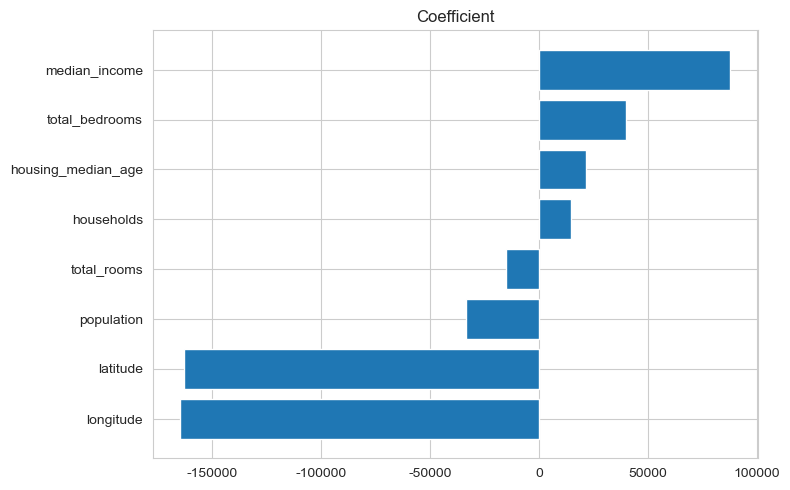

In [50]:
# 시각화하기

plt.figure(figsize=(8,5))
plt.barh(coef_df['feature'],coef_df['coefficient'])
plt.title('Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show